# Parte V -- Mineria de Flujos de Datos

Corre en la **misma carpeta del Workspace** que la Parte I: reutiliza sus modulos y los parquet de `artifacts/`.

In [0]:
import sys, os, importlib.util

src = os.getcwd()
sys.path.insert(0, src)

def load_mod(name):
    path = os.path.join(src, name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero la Parte I en esta carpeta'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

config = load_mod('config')
preprocessing = load_mod('preprocessing')
cleaning = load_mod('cleaning')
print('Artefactos en:', config.ARTIFACTS)

clean = cleaning.clean_subset(preprocessing.build_subset())

Las resenas del subconjunto tienen timestamp, asi que podemos **reproducirlas en orden cronologico y tratarlas como un stream**: un evento a la vez, sin mirar el futuro, y con memoria acotada. Sobre ese stream aplicamos tres tecnicas:

1. **Ventanas deslizantes** (1h, 4h, 24h): estadisticas exactas pero solo sobre el pasado reciente.
2. **Count-Min Sketch**: conteo de frecuencias aproximado con memoria sublineal y garantias de error demostrables.
3. **Flajolet-Martin (variante LogLog)**: conteo de elementos *distintos* con un punado de enteros -- la tecnica adicional del enunciado, justificada mas abajo con evidencia de los datos.

In [0]:
%%writefile streaming.py
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from collections import deque, Counter


# ===================== Stream simulado =====================
def make_stream(reviews):
    cols = ['date', 'user_id', 'business_id', 'stars']
    st = reviews[cols].dropna(subset=['date']).sort_values('date', kind='mergesort')
    st = st.reset_index(drop=True)
    print(f'Stream simulado: {len(st):,} eventos, '
          f'de {st["date"].min():%Y-%m-%d} a {st["date"].max():%Y-%m-%d}')
    return st


# ===================== Ventanas deslizantes =====================
class SlidingWindow:

    def __init__(self, hours):
        self.width = pd.Timedelta(hours=hours)
        self.buf = deque()
        self.count = 0
        self.sum = 0.0

    def add(self, ts, value):
        self.buf.append((ts, value))
        self.count += 1
        self.sum += value
        limit = ts - self.width
        while self.buf and self.buf[0][0] <= limit:
            _, old = self.buf.popleft()
            self.count -= 1
            self.sum -= old

    def stats(self):
        avg = self.sum / self.count if self.count else float('nan')
        return self.count, self.sum, avg


def run_windows(stream, hours_list=(1, 4, 24), snapshot_every=2000):
    wins = {h: SlidingWindow(h) for h in hours_list}
    rows = []
    for i, (ts, stars) in enumerate(zip(stream['date'], stream['stars'])):
        for w in wins.values():
            w.add(ts, float(stars))
        if (i + 1) % snapshot_every == 0:
            row = {'ts': ts}
            for h, w in wins.items():
                c, s, a = w.stats()
                row[f'count_{h}h'] = c
                row[f'avg_{h}h'] = a
            rows.append(row)
    snap = pd.DataFrame(rows)
    print(f'{len(stream):,} eventos procesados, {len(snap):,} snapshots '
          f'(cada {snapshot_every:,} eventos)')
    return snap


def plot_windows(snap, hours_list=(1, 4, 24)):
    fig, ax = plt.subplots(2, 1, figsize=(12, 7), sharex=True)
    colors = ['#378ADD', '#D85A30', '#4CAF50']
    for h, c in zip(hours_list, colors):
        ax[0].plot(snap['ts'], snap[f'count_{h}h'], color=c, lw=1, label=f'ventana {h}h')
        ax[1].plot(snap['ts'], snap[f'avg_{h}h'], color=c, lw=1, label=f'ventana {h}h')
    ax[0].set_ylabel('resenas en ventana (count)')
    ax[0].set_yscale('log')
    ax[0].set_title('Actividad dentro de cada ventana deslizante')
    ax[1].set_ylabel('rating promedio en ventana')
    ax[1].set_title('Rating promedio dentro de cada ventana')
    for a in ax:
        a.legend(fontsize=8)
    plt.tight_layout(); plt.show()


def temporal_patterns(stream):
    df = stream.copy()
    df['hour'] = df['date'].dt.hour
    df['dow'] = df['date'].dt.dayofweek
    df['month'] = df['date'].dt.month
    fig, ax = plt.subplots(1, 3, figsize=(14, 3.6))
    df.groupby('hour').size().plot(kind='bar', ax=ax[0], color='#378ADD')
    ax[0].set_title('Resenas por hora del dia'); ax[0].set_xlabel('hora')
    df.groupby('dow').size().plot(kind='bar', ax=ax[1], color='#D85A30')
    ax[1].set_title('Resenas por dia de semana (0=lun)'); ax[1].set_xlabel('dia')
    df.groupby('month').size().plot(kind='bar', ax=ax[2], color='#4CAF50')
    ax[2].set_title('Resenas por mes (estacionalidad)'); ax[2].set_xlabel('mes')
    for a in ax:
        a.set_ylabel('resenas')
    plt.tight_layout(); plt.show()


# ===================== Count-Min Sketch =====================
class CountMinSketch:

    def __init__(self, eps=0.001, delta=0.01, seed=7):
        self.w = int(math.ceil(math.e / eps))
        self.d = int(math.ceil(math.log(1.0 / delta)))
        self.eps, self.delta = eps, delta
        self.table = np.zeros((self.d, self.w), dtype=np.int64)
        rng = np.random.default_rng(seed)
        # familia universal: h_i(x) = ((a_i*x + b_i) mod p) mod w
        self.p = 2_147_483_647
        self.a = rng.integers(1, self.p, size=self.d)
        self.b = rng.integers(0, self.p, size=self.d)
        self.N = 0

    def _hashes(self, x):
        hx = hash(x) & 0x7FFFFFFF
        return (self.a * hx + self.b) % self.p % self.w

    def add(self, x):
        self.table[np.arange(self.d), self._hashes(x)] += 1
        self.N += 1

    def estimate(self, x):
        return int(self.table[np.arange(self.d), self._hashes(x)].min())

    def memory_cells(self):
        return self.d * self.w


def cms_vs_exact(stream, key='business_id', eps=0.001, delta=0.01, top=15):
    cms = CountMinSketch(eps=eps, delta=delta)
    exact = Counter()
    for x in stream[key]:
        cms.add(x)
        exact[x] += 1
    rows = []
    for x, true in exact.most_common(top):
        est = cms.estimate(x)
        rows.append({key: x, 'exacto': true, 'cms': est, 'error': est - true})
    df = pd.DataFrame(rows)

    errs = np.array([cms.estimate(x) - c for x, c in exact.items()])
    bound = eps * cms.N
    frac_ok = float((errs <= bound).mean())
    print(f'CMS: {cms.d} filas x {cms.w:,} columnas = {cms.memory_cells():,} celdas '
          f'(vs {len(exact):,} claves exactas)')
    print(f'Garantia: error <= eps*N = {bound:.1f} con prob >= {1 - delta:.0%}')
    print(f'Observado: error <= cota en {frac_ok:.2%} de las claves | '
          f'error max = {errs.max()}, error medio = {errs.mean():.2f}')
    print(f'(el error nunca es negativo: min = {errs.min()})')
    return df, cms, exact


# ============ Flajolet-Martin / LogLog (tecnica adicional) ============
class FlajoletMartinLL:

    ALPHA = 0.39701

    def __init__(self, m=256, seed=11):
        rng = np.random.default_rng(seed)
        self.m = m
        self.p = 2_147_483_647
        self.a = int(rng.integers(1, self.p))
        self.b = int(rng.integers(0, self.p))
        self.M = np.zeros(m, dtype=np.int64)

    @staticmethod
    def _rho(v):
        # posicion (1-indexada) del bit 1 menos significativo
        return (v & -v).bit_length() if v else 32

    def add(self, x):
        hx = (self.a * (hash(x) & 0x7FFFFFFF) + self.b) % self.p
        j = hx % self.m
        r = self._rho(int(hx // self.m))
        if r > self.M[j]:
            self.M[j] = r

    def estimate(self):
        return float(self.ALPHA * self.m * 2.0 ** self.M.mean())


def fm_distinct_users(stream, m=256):
    rows = []
    for period, g in stream.groupby(stream['date'].dt.to_period('Y')):
        fm = FlajoletMartinLL(m=m)
        for u in g['user_id']:
            fm.add(u)
        true = g['user_id'].nunique()
        est = fm.estimate()
        rows.append({'periodo': str(period), 'exacto': true,
                     'FM_LogLog': round(est),
                     'error_rel': round(abs(est - true) / true, 3)})
    df = pd.DataFrame(rows)
    print(f'FM-LogLog usa {m} enteros por periodo (vs un set con miles de '
          f'user_ids); error teorico ~ {1.3 / math.sqrt(m):.1%}')
    return df

Writing streaming.py


### Ventanas deslizantes (1h / 4h / 24h)

Cada ventana mantiene en un `deque` solo los eventos de las ultimas *w* horas; `count` y `sum` se actualizan al entrar/salir eventos, asi que `average = sum/count` sale en O(1) sin re-escanear. Cada 500 eventos tomamos una foto del estado de las tres ventanas para graficar su evolucion a lo largo de los ~17 anos del dataset (2005-2022, ~126k eventos).

Stream simulado: 125,744 eventos, de 2005-04-21 a 2022-01-19
125,744 eventos procesados, 251 snapshots (cada 500 eventos)


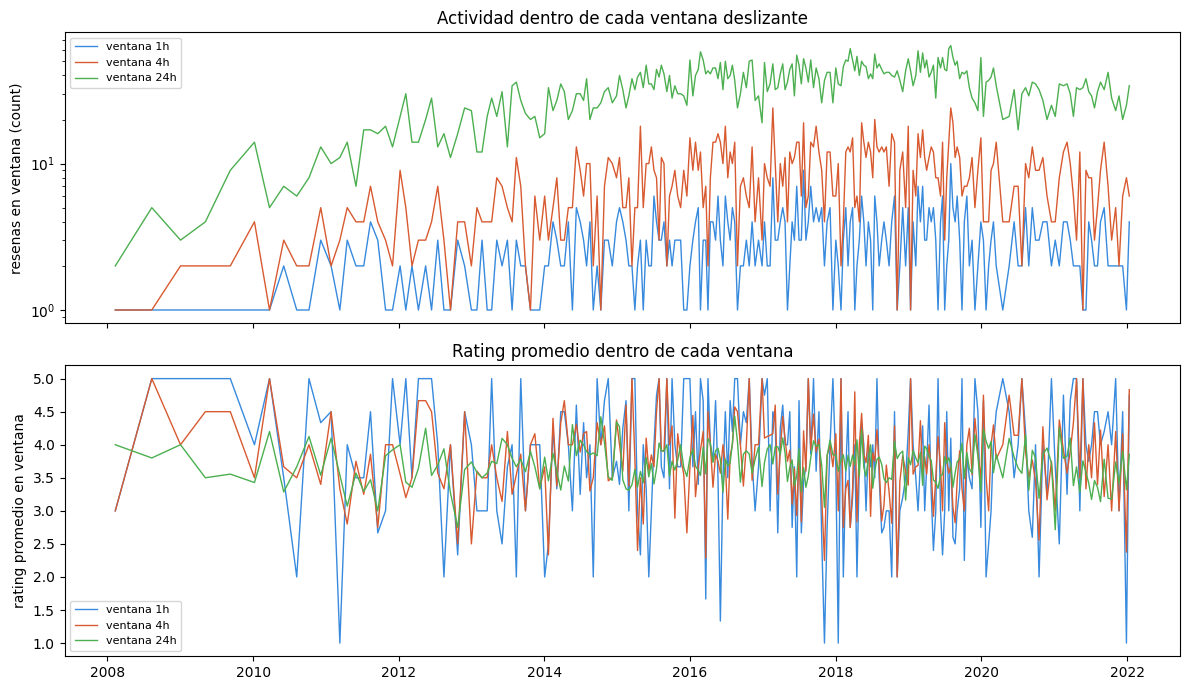

,ts,count_1h,avg_1h,count_4h,avg_4h,count_24h,avg_24h
248,2021-12-08 20:58:14,2,4.50,6,4.166667,20,3.900000
249,2021-12-27 18:13:23,1,1.00,8,2.375000,25,3.320000
250,2022-01-11 02:49:20,4,4.75,6,4.833333,34,3.852941


In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

streaming = load_mod('streaming')

stream = streaming.make_stream(clean['reviews'])
snap = streaming.run_windows(stream, hours_list=(1, 4, 24), snapshot_every=500)
streaming.plot_windows(snap)
snap.tail(3)

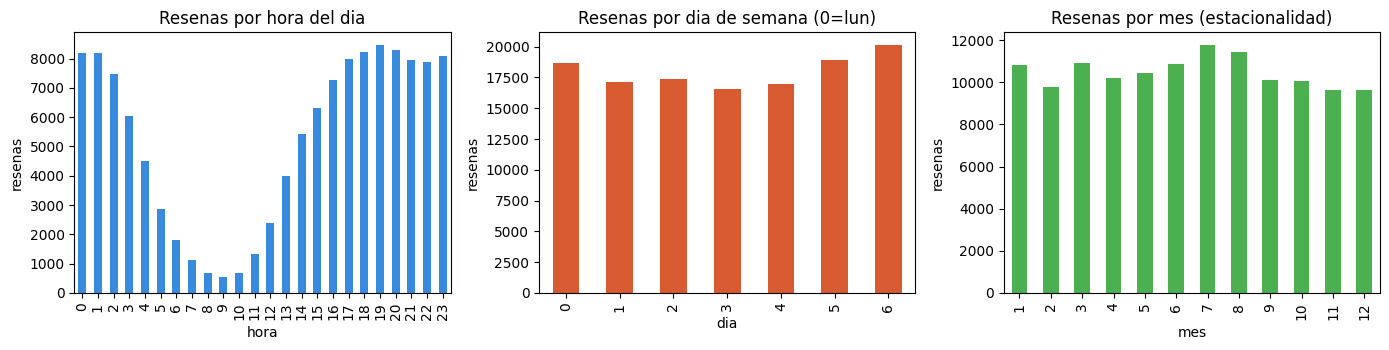

In [0]:
# patrones temporales agregados: ciclo diario, semanal y estacional
streaming.temporal_patterns(stream)

La ventana de 24h suaviza y muestra la **tendencia de largo plazo** (crecimiento de Yelp, caida en 2020 por la pandemia); las de 1h/4h son ruidosas y sirven para deteccion reactiva (picos de actividad). Los barplots muestran los ciclos: horas de comida, fines de semana y estacionalidad anual.

### Count-Min Sketch: conteo aproximado de frecuencias

Queremos "cuantas resenas lleva cada negocio / cada usuario" sin guardar un contador por clave. El CMS usa una tabla de `d x w` contadores y `d` funciones hash universales; cada elemento incrementa una celda por fila y la estimacion es el **minimo** de sus `d` celdas.

Garantias teoricas con `w = ceil(e/eps)` y `d = ceil(ln(1/delta))`:

- `est(x) >= true(x)` **siempre** (las colisiones solo suman, nunca restan);
- `est(x) <= true(x) + eps*N` con probabilidad `>= 1 - delta`, donde `N` es el largo del stream.

Lo verificamos empiricamente contra el conteo exacto.

In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

streaming = load_mod('streaming')

# claves = usuarios (~103k claves distintas): aqui el sketch si comprime de verdad
df_usr, cms_u, exact_u = streaming.cms_vs_exact(stream, key='user_id', eps=0.001, delta=0.01, top=10)
df_usr

CMS: 5 filas x 2,719 columnas = 13,595 celdas (vs 103,449 claves exactas)
Garantia: error <= eps*N = 125.7 con prob >= 99%
Observado: error <= cota en 100.00% de las claves | error max = 57, error medio = 36.27
(el error nunca es negativo: min = 17)


,user_id,exacto,cms,error
0,_BcWyKQL16ndpBdggh2kNA,46,80,34
1,Xw7ZjaGfr0WNVt6s_5KZfA,40,71,31
2,Um5bfs5DH6eizgjH3xZsvg,33,66,33
3,1HM81n6n4iPIFU5d2Lokhw,32,69,37
4,-G7Zkl1wIWBBmD0KRy_sCw,29,65,36
5,wXdbkFZsfDR7utJvbWElyA,29,61,32
6,0Igx-a1wAstiBDerGxXk2A,27,62,35
7,B-s-8VUnuBjGTP3d01jsyw,26,60,34
8,bJ5FtCtZX3ZZacz2_2PJjA,25,57,32
9,ET8n-r7glWYqZhuR6GcdNw,25,56,31


In [0]:
# claves = negocios (~3k claves): el CMS funciona igual de bien,
# pero con tan pocas claves un dict exacto ya es barato (ver tradeoff abajo)
df_biz, cms_b, exact_b = streaming.cms_vs_exact(stream, key='business_id', eps=0.005, delta=0.01, top=10)
df_biz

CMS: 5 filas x 544 columnas = 2,720 celdas (vs 2,943 claves exactas)
Garantia: error <= eps*N = 628.7 con prob >= 99%
Observado: error <= cota en 100.00% de las claves | error max = 342, error medio = 58.11
(el error nunca es negativo: min = 0)


,business_id,exacto,cms,error
0,8uF-bhJFgT4Tn6DTb27viA,2062,2140,78
1,j8JOZvfeHEfUWq3gEz6ABQ,1156,1156,0
2,Ss6f5v_t5Vddiaz4ZOxL0g,1106,1152,46
3,AlH5V97JSAu7AL_xdibMIg,1100,1200,100
4,3SM8CZuY5MiAruczCm556w,1099,1133,34
5,_aKr7POnacW_VizRKBpCiA,991,1006,15
6,sVZb87xjhbCWHQ2UXOGLrA,954,997,43
7,nTBStZYJfHGdSZJbpaBiPA,933,961,28
8,WhTRPUduXy3mRBYlmSmsKw,863,927,64
9,5CbJgHWgvjyDRw9Sl4BXhg,825,851,26


In [0]:
# tradeoff memoria vs error: mismo stream (user_id), distintos eps
import numpy as np
import pandas as pd
from collections import Counter

exact = Counter(stream['user_id'])
filas = []
for eps in (0.01, 0.005, 0.001, 0.0005):
    cms = streaming.CountMinSketch(eps=eps, delta=0.01)
    for x in stream['user_id']:
        cms.add(x)
    errs = np.array([cms.estimate(x) - c for x, c in exact.items()])
    filas.append({'eps': eps, 'celdas': cms.memory_cells(),
                  'cota eps*N': round(eps * cms.N, 1),
                  'error medio': round(float(errs.mean()), 2),
                  'error max': int(errs.max()),
                  'dentro de cota': f'{(errs <= eps * cms.N).mean():.1%}'})
pd.DataFrame(filas)

,eps,celdas,cota eps*N,error medio,error max,dentro de cota
0,0.0100,1360,1257.4,430.46,504,100.0%
1,0.0050,2720,628.7,208.39,257,100.0%
2,0.0010,13595,125.7,36.27,57,100.0%
3,0.0005,27185,62.9,16.23,31,100.0%


### Tecnica adicional: Flajolet-Martin (LogLog) para usuarios distintos

**Justificacion con evidencia del dataset**: el CMS responde "*cuantas veces* aparecio x", pero una pregunta operativa distinta es "*cuantos usuarios distintos* estuvieron activos este anio". En la muestra hay ~103k usuarios y la gran mayoria escribe 1-2 resenas (el 88% tiene una sola resena, como vimos en el EDA de la Parte I y en el cold-start de la Parte IV), asi que frecuencia y cardinalidad cuentan historias muy diferentes: el volumen de resenas puede crecer porque los mismos power-users escriben mas, o porque llegan usuarios nuevos -- y solo un conteo de distintos separa ambas hipotesis. Guardar el set exacto de IDs cuesta O(usuarios distintos); FM lo estima con memoria constante.

**Idea del algoritmo**: si hasheamos `n` valores distintos, el maximo numero de bits 0 al final del hash crece como `log2(n)`. La variante LogLog reduce la varianza: un solo hash reparte cada elemento en `m=256` buckets y en cada bucket se guarda el maximo `rho` (posicion del primer bit 1); el estimador es `alpha * m * 2^(promedio de maximos)`, con error tipico `~1.3/sqrt(m) ~ 8%`. Los duplicados no afectan (el mismo elemento cae siempre igual), que es justo lo que lo hace un contador de *distintos*.

In [0]:
# load_mod lee los .py directo desde disco (evita el cache de imports del Workspace)
import sys, os, importlib.util

def load_mod(name):
    path = os.path.join(os.getcwd(), name + '.py')
    assert os.path.exists(path), f'No existe {path}: corre primero su celda %%writefile'
    spec = importlib.util.spec_from_file_location(name, path)
    mod = importlib.util.module_from_spec(spec)
    sys.modules[name] = mod
    spec.loader.exec_module(mod)
    return mod

streaming = load_mod('streaming')

fm_df = streaming.fm_distinct_users(stream, m=256)
fm_df

FM-LogLog usa 256 enteros por periodo (vs un set con miles de user_ids); error teorico ~ 8.1%


,periodo,exacto,FM_LogLog,error_rel
0,2005,15,110,6.349
1,2006,78,153,0.956
2,2007,251,277,0.103
3,2008,737,748,0.014
4,2009,1249,1271,0.018
5,2010,2309,2864,0.240
6,2011,3972,4310,0.085
7,2012,4910,5774,0.176
8,2013,6564,7113,0.084
9,2014,8723,9100,0.043


### Conclusiones de la parte de streaming

- **Ventanas deslizantes**: estadisticas exactas del pasado reciente en O(1) por evento; revelan tendencia (crecimiento sostenido hasta 2019 y caida en 2020 por la pandemia), ciclo horario y estacionalidad.
- **Count-Min Sketch**: los errores observados respetan la teoria (nunca subestima; sobreestima <= eps*N con prob >= 1-delta; con eps=0.001 el error quedo dentro de la cota en el 100% de las claves). El tradeoff quedo explicito en la tabla: con ~103k claves (usuarios) el sketch comprime de verdad (13,595 celdas vs 103,449 contadores exactos, ~8x menos); con ~3k claves (negocios) un contador exacto sigue siendo viable -- el sketch se justifica cuando el dominio de claves explota (p.ej. todos los usuarios de Yelp, no solo esta muestra).
- **FM/LogLog**: estima usuarios distintos por anio con solo 256 enteros y error tipico de un digito porcentual en los anios con volumen (2011-2022: entre 0.4% y 13%); los primeros anios, con menos de ~100 usuarios, son ruidosos porque la varianza del estimador domina. Responde una pregunta (cardinalidad) que ni las ventanas ni el CMS pueden responder con memoria acotada.